In [4]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 指定默认
plt.rcParams['axes.unicode_minus'] = False
# ===== 配置 =====

In [ ]:
###  ['e', 'd2m', 'sde', 'sp', 't2m', 'tp', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4']
###  ['ro', 'v10', 'ssr', 'ssrd', 'str', 'strd']
###  ['e', 'rh', 'ro', 'sde', 'sp', 'ssrd',  'ssr', 'strd', 'str', 't2m', 'tp', 'v10']
# var: e, rh(d2m), sde, sp, t2m, tp, ro, v10, ssr, ssrd, str, strd
# stmi: stl1, stl2, stl3, stl4 swvl1, swvl2, swvl3, swvl4
# factors = ['Evapotranspiration', '2m Temperature', 'Total Precipitation', 'Surface Pressure', 'Snow Depth', 
        #    '10m Wind Speed', 'Surface Net Radiation', 'Surface Net Downward Radiation', 
        #    'Surface Solar Radiation', 'Surface Solar Radiation Downward', 'Runoff', 'Relative Humidity']
# units = ['m', '°C', 'm', 'Pa', 'm', 'm/s', 'J m-2', 'J m-2', 'J m-2', 'J m-2', 'm', '%']

C:\Users\28213\AppData\Local\Temp\ipykernel_31316\3325157494.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='1997-01', end='2022-01', freq='M')


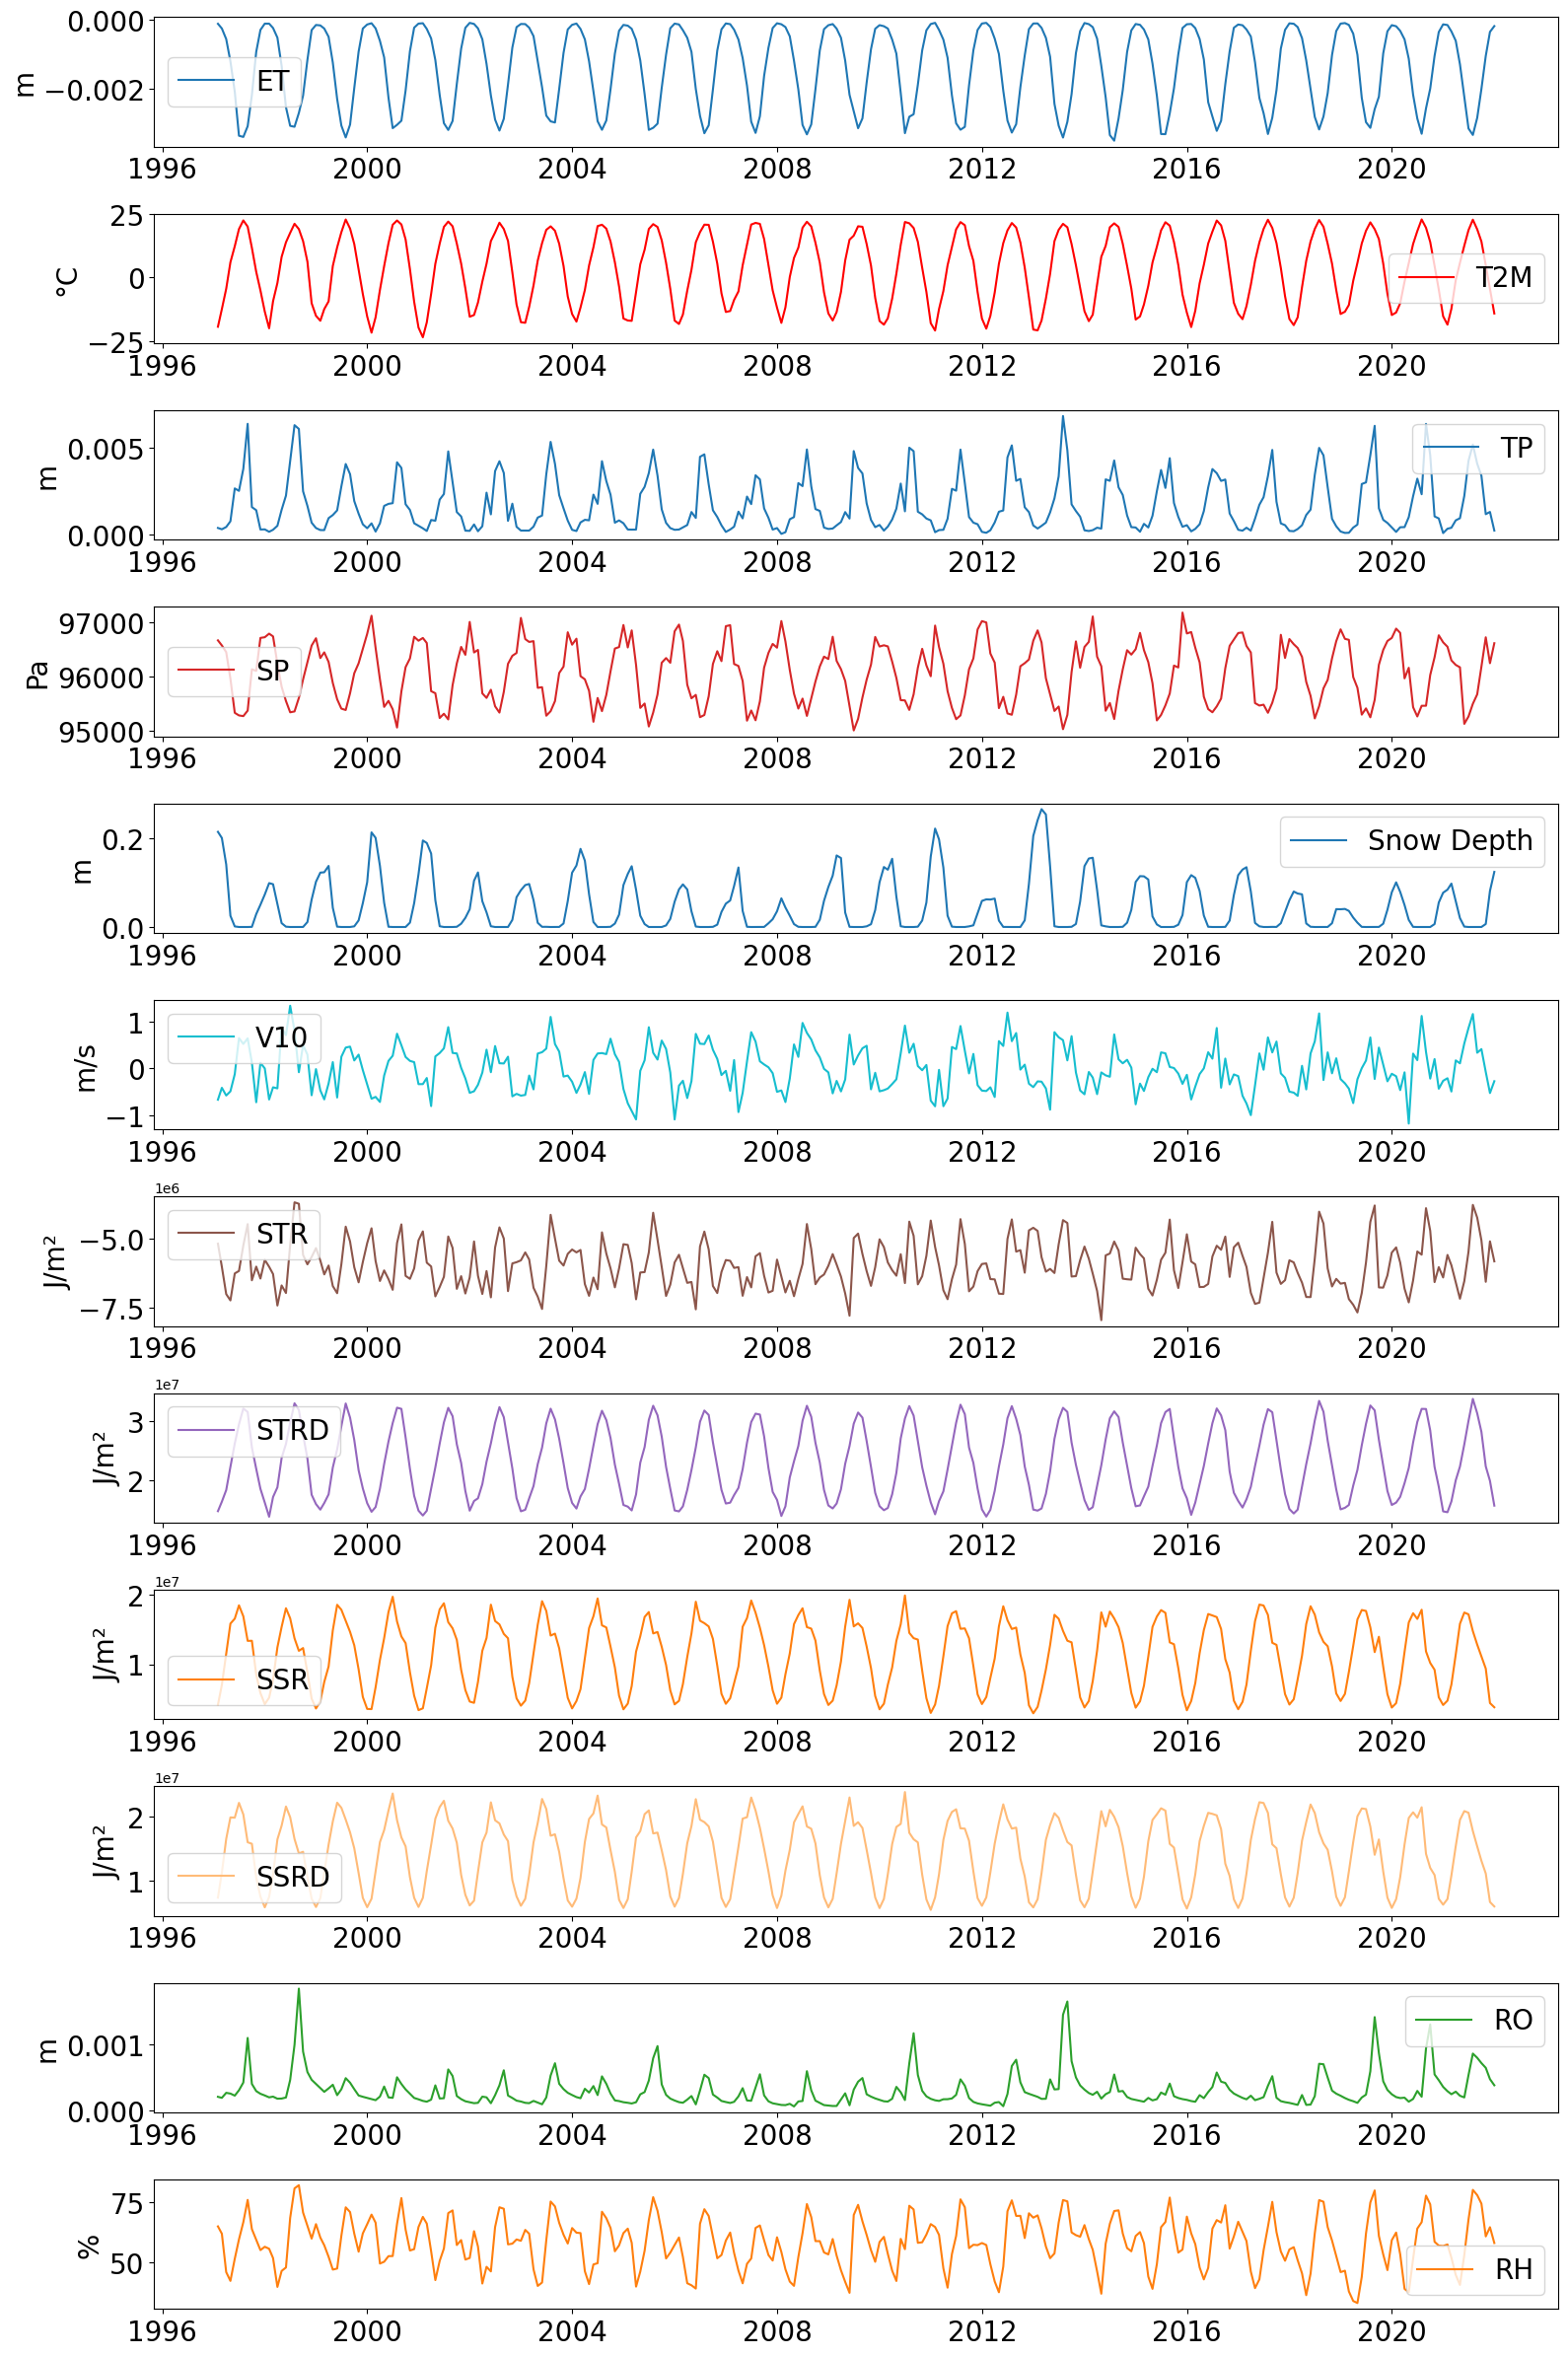

In [2]:
# 气候因子年均变化趋势
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# 读取所有气候变量数据 并绘制年均值折线图
e = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/e.xlsx', index_col=0)   # m of water equivalent
t2m = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/t2m.xlsx', index_col=0) -273.15 # T
tp = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/tp.xlsx', index_col=0)  # m
sp = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/sp.xlsx', index_col=0)  # Pa
sde = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/sde.xlsx', index_col=0)  # m
v10 = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/v10.xlsx', index_col=0)  # m/s
str = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/str.xlsx', index_col=0)  # J m-2
strd = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/strd.xlsx', index_col=0)  # J m-2
ssr = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ssr.xlsx', index_col=0)  # J m-2
ssrd = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ssrd.xlsx', index_col=0)  #J m-2
ro = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ro.xlsx', index_col=0)  # m
rh = pd.read_excel("D:/Permafrost/EN_MASK/var/excel/relative_humidity.xlsx", index_col=0)  # %
colors = [ '#1f77b4',  # Evapotranspiration (蓝色)
          '#ff0000',  # 2m Temperature (红色)
        '#1f77b4',   # Total Precipitation (蓝色)
        '#d62728',  # Surface Pressure (红色)
        '#1f77b4', # Snow Depth (蓝色)
        '#17becf',   # 10m Wind Speed (青色)
        '#8c564b',  # Surface Net Radiation (棕色)
        '#9467bd', # Surface Net Downward Radiation (紫色)
        '#ff7f0e',  # Surface Solar Radiation (橙色)
        '#ffbb78', # Surface Solar Radiation Downward (浅橙色)
        '#2ca02c',  # Runoff (绿色)
        '#ff7f0e',  # Relative Humidity (橙色)
]

# 将因子单位生成一个列表
units = ['m', '°C', 'm', 'Pa', 'm', 'm/s', 'J/m²', 'J/m²', 'J/m²', 'J/m²', 'm', '%']
labels = ['e', 't2m', 'tp', 'sp', 'sde', 'v10', 'str', 'strd', 'ssr', 'ssrd', 'ro', 'rh']
factors = ['ET', 'T2M', 'TP', 'SP', 'Snow Depth', 'V10', 'STR', 'STRD', 
           'SSR', 'SSRD', 'RO', 'RH']
# 计算年均值
var = [e, t2m, tp, sp, sde, v10, str, strd, ssr, ssrd, ro, rh]
# 创建年份列表
years = range(1997, 2022)  # 假设数据对应25年
# 创建子图
fig, axs = plt.subplots(12, 1, figsize=(16, 24))  # 6行2列的子图
axs = axs.flatten()  # 将二维数组转换为一维，方便访问每个子图
# 绘制每个因子的年均值折线图
def plot_with_trend(ax, x, y, label, unit, color):
    dates = pd.date_range(start='1997-01', end='2022-01', freq='M')
    ax.plot(dates, y, label=label, color=color)
    # ax.set_xlabel('Year')
    ax.set_ylabel(unit, fontsize=20)
    ax.tick_params(labelsize=20)
    ax.legend(fontsize=20)
    # print(f"整体变化幅度: {change_range:.4f} {unit}")
    # print(f"起始值: {p(x)[0]:.4f}，结束值: {p(x)[-1]:.4f}")
    # print(f"百分比变化幅度: {percentage_change:.2f}%")
for i, (factor, unit, label, color) in enumerate(zip(factors, units, labels, colors)):
    plot_with_trend(axs[i], var[i].index.year, var[i].iloc[:, 0], factor, unit, color)

# 显示图表
plt.tight_layout()
plt.show()

In [8]:
import warnings
warnings.filterwarnings("ignore")
e_y = e.resample('A').mean()
t2m_y = t2m.resample('A').mean()
tp_y = tp.resample('A').mean()
sp_y = sp.resample('A').mean()
sde_y = sde.resample('A').mean()
v10_y = v10.resample('A').mean()
str_y = str.resample('A').mean()
strd_y = strd.resample('A').mean()
ssr_y = ssr.resample('A').mean()
ssrd_y = ssrd.resample('A').mean()
ro_y = ro.resample('A').mean()
rh_y = rh.resample('A').mean()
var_y = [e_y, t2m_y, tp_y, sp_y, sde_y, v10_y, str_y, strd_y, ssr_y, ssrd_y, ro_y, rh_y]
# 创建年份列表
years = range(1997, 2022)  # 假设数据对应25年
# 创建子图
fig, axs = plt.subplots(4, 3, figsize=(16, 12), dpi=600)  # 6行2列的子图
axs = axs.flatten()  # 将二维数组转换为一维，方便访问每个子图
# 绘制每个因子的年均值折线图
def plot_with_trend(ax, x, y, label, unit, color):
    ax.plot(x, y, marker='o', label=label, color=color)
    # 计算线性趋势
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    print(f"{z[0]:.3e}")
    ax.plot(x, p(x), linestyle='--', color=color)
    # ax.set_xlabel('Year')
    ax.set_ylabel(unit, fontsize=20)
    ax.tick_params(labelsize=20)
    ax.legend(fontsize=20)
    change_range = p(x)[-1] - p(x)[0]
    percentage_change = (change_range / abs(p(x)[0])) * 100
    print(f"{label}:整体变化幅度: {change_range:.6f} {unit}")
    # print(f"起始值: {p(x)[0]:.4f}，结束值: {p(x)[-1]:.4f}")
    print(f"{label}:百分比变化幅度: {percentage_change:.2f}%")
for i, (factor, unit, label, color) in enumerate(zip(factors, units, labels, colors)):
    plot_with_trend(axs[i], var_y[i].index.year, var_y[i].iloc[:, 0], factor, unit, color)

# 显示图表
plt.tight_layout()
plt.show()

3.191e-07
ET:整体变化幅度: 0.000008 m
ET:百分比变化幅度: 0.55%
3.401e-02
T2M:整体变化幅度: 0.816323 °C
T2M:百分比变化幅度: 28.38%
5.415e-06
TP:整体变化幅度: 0.000130 m
TP:百分比变化幅度: 8.04%
1.356e+00
SP:整体变化幅度: 32.549832 Pa
SP:百分比变化幅度: 0.03%
-5.966e-04
Snow Depth:整体变化幅度: -0.014317 m
Snow Depth:百分比变化幅度: -27.48%
-1.308e-03
V10:整体变化幅度: -0.031398 m/s
V10:百分比变化幅度: -189.64%
-1.646e+02
STR:整体变化幅度: -3949.517692 J/m²
STR:百分比变化幅度: -0.07%
1.145e+04
STRD:整体变化幅度: 274910.249231 J/m²
STRD:百分比变化幅度: 1.21%
-1.698e+03
SSR:整体变化幅度: -40752.852308 J/m²
SSR:百分比变化幅度: -0.36%
-1.134e+04
SSRD:整体变化幅度: -272114.378462 J/m²
SSRD:百分比变化幅度: -1.89%
1.773e-06
RO:整体变化幅度: 0.000043 m
RO:百分比变化幅度: 14.81%
-6.104e-02
RH:整体变化幅度: -1.464907 %
RH:百分比变化幅度: -2.49%


In [ ]:
ex_dir = os.listdir('D:/Permafrost/EN_MASK/var/excel')
colors = {
    'e': '#1f77b4',  # Evapotranspiration (蓝色)
    'rh': '#ff7f0e',  # Relative Humidity (橙色)
    'ro': '#2ca02c',  # Runoff (绿色)
    'sde': '#1f77b4', # Snow Depth (蓝色)
    'sp': '#d62728',  # Surface Pressure (红色)
    'ssrd': '#ffbb78', # Surface Solar Radiation Downward (浅橙色)
    'ssr': '#ff7f0e',  # Surface Solar Radiation (橙色)
    'strd': '#9467bd', # Surface Net Downward Radiation (紫色)
    'str': '#8c564b',  # Surface Net Radiation (棕色)
    't2m': '#ff0000',  # 2m Temperature (红色)
    'tp': '#1f77b4',   # Total Precipitation (蓝色)
    'v10': '#17becf'   # 10m Wind Speed (青色)
}
vn = ['e', 'rh', 'ro', 'sde', 'sp', 'ssr', 'ssrd', 'str', 'strd', 't2m', 'tp', 'v10']
units = ['m', '%', 'm', 'm', 'Pa', 'J m-2', 'J m-2', 'J m-2', 'J m-2', '°C', 'm', 'm/s']
factors = ['Evapotranspiration', 'Relative Humidity', 'Runoff', 'Snow Depth', 'Surface Pressure', 
           'Surface Solar Radiation', 'Surface Solar Radiation Downward', 'Surface Net Radiation', 'Surface Net Downward Radiation', 
           '2m Temperature', 'Total Precipitation', '10m Wind Speed']
for i,ex in enumerate(ex_dir):
    df = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/' + ex)
    df['valid_time'] = pd.to_datetime(df['valid_time'])
    df.set_index('valid_time', inplace=True)
    df = df.resample('A').mean()
    df.plot(kind='line', color=colors[vn[i]], label=factors[i] + ' (' + units[i] + ')')


In [ ]:
# 气候因子的多年平均绘制
var_dir = os.listdir('D:/Permafrost/EN_MASK/var/nc')
vn = ['e', 'rh', 'ro', 'sde', 'sp', 'ssrd',  'ssr', 'strd', 'str', 't2m', 'tp', 'v10']
units = ['m', '%', 'm', 'm', 'Pa', 'J/m²', 'J/m²', 'J/m²', 'J/m²', '°C', 'm', 'm/s']
# factors = ['Evapotranspiration', 'Relative Humidity', 'Runoff', 'Snow Depth', 'Surface Pressure', 
#            'Surface Solar Radiation Downward', 'Surface Solar Radiation', 'Surface Net Downward Radiation', 'Surface Net Radiation', 
#            '2m Temperature', 'Total Precipitation', '10m Wind Speed']
factors = ['ET', 'RH', 'RO', 'SDE', 'SP', 'SSRD', 'SSR', 'STRD', 'STR', 'T2M', 'TP', 'V10']
# ET, RH, RO, SDE, SP, SSRD, SSR, STRD, STR, T2M, TP, V10
color_maps = {
    'e': 'Blues',               # Evapotranspiration
    'rh': 'coolwarm',           # Relative Humidity
    'ro': 'YlGn',               # Runoff
    'sde': 'Blues',             # Snow Depth
    'sp': 'coolwarm',           # Surface Pressure
    'ssrd': 'YlOrRd',           # Surface Solar Radiation Downward
    'ssr': 'YlOrRd',            # Surface Solar Radiation
    'strd': 'coolwarm',         # Surface Net Downward Radiation
    'str': 'coolwarm',          # Surface Net Radiation
    't2m': 'coolwarm',          # 2m Temperature
    'tp': 'Blues',              # Total Precipitation
    'v10': 'YlGnBu'             # 10m Wind Speed
}

for i,var_nc in enumerate(var_dir):
    cmap = color_maps[vn[i]]
    var_data = xr.open_dataset('D:/Permafrost/EN_MASK/var/nc/' + var_nc)[vn[i]].mean(dim='valid_time')
    if vn[i] == 't2m':var_data = var_data - 273.15
    elif vn[i] == 'e':var_data = var_data * -1
    # 创建一个图形
    fig, axe = plt.subplots(figsize=(7, 6), constrained_layout=True)
    # 绘制图像
    im = var_data.plot.imshow(cmap=cmap, add_colorbar=False)
    # 隐藏刻度并保留边框
    axe.tick_params(axis='both', which='both', length=0)
    # 取消边框
    for s in ['top', 'right', 'bottom', 'left']:
        axe.spines[s].set_visible(False)
    # 隐藏 x 和 y 轴刻度
    axe.set_xticks([])
    axe.set_yticks([])
    axe.set_xlabel('')
    axe.set_ylabel('')
    axe.set_title('')
    # 显示图形
    plt.show()
    # 绘制色带
    fig_cb, ax_cb = plt.subplots(figsize=(7, 0.2), constrained_layout=True)
    cbar = fig.colorbar(im, cax=ax_cb, orientation='horizontal', fraction=0.9, pad=0.2)
    cbar.set_label(f'{factors[i]} ({units[i]})', fontsize=30)
    cbar.ax.tick_params(labelsize=30)
    plt.show()


In [ ]:
# 气候因子的年均变化趋势绘制
var_dir = os.listdir('D:/Permafrost/EN_MASK/var/nc')
vn = ['e', 'rh', 'ro', 'sde', 'sp', 'ssrd',  'ssr', 'strd', 'str', 't2m', 'tp', 'v10']
units = ['m/yr', '%/yr', 'm/yr', 'm/yr', 'Pa/yr', 'J/m²/yr', 'J/m²/yr', 'J/m²/yr', 'J/m²/yr', '°C/yr', 'm/yr', 'm/s/yr']
# factors = ['Evapotranspiration', 'Relative Humidity', 'Runoff', 'Snow Depth', 'Surface Pressure', 
#            'Surface Solar Radiation Downward', 'Surface Solar Radiation', 'Surface Net Downward Radiation', 'Surface Net Radiation', 
#            '2m Temperature', 'Total Precipitation', '10m Wind Speed']
factors = ['ET Trend', 'RH Trend', 'RO Trend', 'SDE Trend', 'SP Trend', 'SSRD Trend', 'SSR Trend', 'STRD Trend', 'STR Trend', 'T2M Trend', 'TP Trend', 'V10 Trend']
# ET, RH, RO, SDE, SP, SSRD, SSR, STRD, STR, T2M, TP, V10
color_maps = {
    'e': 'Blues',               # Evapotranspiration
    'rh': 'coolwarm',           # Relative Humidity
    'ro': 'YlGn',               # Runoff
    'sde': 'Blues',             # Snow Depth
    'sp': 'coolwarm',           # Surface Pressure
    'ssrd': 'YlOrRd',           # Surface Solar Radiation Downward
    'ssr': 'YlOrRd',            # Surface Solar Radiation
    'strd': 'coolwarm',         # Surface Net Downward Radiation
    'str': 'coolwarm',          # Surface Net Radiation
    't2m': 'coolwarm',          # 2m Temperature
    'tp': 'Blues',              # Total Precipitation
    'v10': 'YlGnBu'             # 10m Wind Speed
}

for i,var_nc in enumerate(var_dir):
    cmap = color_maps[vn[i]]
    var_data_f = xr.open_dataset('D:/Permafrost/EN_MASK/var/nc/' + var_nc)[vn[i]][:12].mean(dim='valid_time')
    var_data_n = xr.open_dataset('D:/Permafrost/EN_MASK/var/nc/' + var_nc)[vn[i]][-12:].mean(dim='valid_time')
    var_data = (var_data_n - var_data_f) / 25
    if vn[i] == 't2m':var_data = var_data - 273.15
    elif vn[i] == 'e':var_data = var_data * -1
    # 创建一个图形
    fig, axe = plt.subplots(figsize=(7, 6), constrained_layout=True)
    # 绘制图像
    im = var_data.plot.imshow(cmap=cmap, add_colorbar=False)
    # 隐藏刻度并保留边框
    axe.tick_params(axis='both', which='both', length=0)
    # 取消边框
    for s in ['top', 'right', 'bottom', 'left']:
        axe.spines[s].set_visible(False)
    # 隐藏 x 和 y 轴刻度
    axe.set_xticks([])
    axe.set_yticks([])
    axe.set_xlabel('')
    axe.set_ylabel('')
    axe.set_title('')
    # 显示图形
    plt.show()
    # 绘制色带
    fig_cb, ax_cb = plt.subplots(figsize=(7, 0.2), constrained_layout=True)
    cbar = fig.colorbar(im, cax=ax_cb, orientation='horizontal', fraction=0.9, pad=0.2)
    cbar.set_label(f'{factors[i]} ({units[i]})', fontsize=30)
    cbar.ax.tick_params(labelsize=30)
    plt.show()


In [ ]:
# 每个月的25年平均值
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取所有气候变量数据
e = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/e.xlsx', index_col=0)   # m of water equivalent
t2m = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/t2m.xlsx', index_col=0) -273.15 # T
tp = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/tp.xlsx', index_col=0)  # m
sp = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/sp.xlsx', index_col=0)  # Pa
sde = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/sde.xlsx', index_col=0)  # m
v10 = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/v10.xlsx', index_col=0)  # m/s
str = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/str.xlsx', index_col=0)  # J m²
strd = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/strd.xlsx', index_col=0)  # J m²
ssr = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ssr.xlsx', index_col=0)  # J m²
ssrd = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ssrd.xlsx', index_col=0)  #J m²
ro = pd.read_excel('D:/Permafrost/EN_MASK/var/excel/ro.xlsx', index_col=0)  # m
rh = pd.read_excel("D:/Permafrost/EN_MASK/var/excel/relative_humidity.xlsx", index_col=0)  # %

# 将因子单位生成一个列表
units = ['m', '°C', 'm', 'Pa', 'm', 'm/s', 'J/m²', 'J/m²', 'J/m²', 'J/m²', 'm', '%']
labels = ['e', 't2m', 'tp', 'sp', 'sde', 'v10', 'str', 'strd', 'ssr', 'ssrd', 'ro', 'rh']
factors = ['ET', 'T2m', 'TP', 'SP', 'SDE', 'V10', 'STR', 'STRD', 'SSR', 'SSRD', 'RO', 'RH']
colors = [ '#1f77b4',  # Evapotranspiration (蓝色)
          '#ff0000',  # 2m Temperature (红色)
        '#1f77b4',   # Total Precipitation (蓝色)
        '#d62728',  # Surface Pressure (红色)
        '#1f77b4', # Snow Depth (蓝色)
        '#17becf',   # 10m Wind Speed (青色)
        '#8c564b',  # Surface Net Radiation (棕色)
        '#9467bd', # Surface Net Downward Radiation (紫色)
        '#ff7f0e',  # Surface Solar Radiation (橙色)
        '#ffbb78', # Surface Solar Radiation Downward (浅橙色)
        '#2ca02c',  # Runoff (绿色)
        '#ff7f0e',  # Relative Humidity (橙色)
]

# 计算月均值
e_m = e.resample('M').mean()
t2m_m = t2m.resample('M').mean()
tp_m = tp.resample('M').mean()
sp_m = sp.resample('M').mean()
sde_m = sde.resample('M').mean()
v10_m = v10.resample('M').mean()
str_m = str.resample('M').mean()
strd_m = strd.resample('M').mean()
ssr_m = ssr.resample('M').mean()
ssrd_m = ssrd.resample('M').mean()
ro_m = ro.resample('M').mean()
rh_m = rh.resample('M').mean()

# 将月均值存储在一个列表中
var_m = [e_m, t2m_m, tp_m, sp_m, sde_m, v10_m, str_m, strd_m, ssr_m, ssrd_m, ro_m, rh_m]

# 计算每个月的25年平均值
monthly_avg = []
for var in var_m:
    # 提取每个月的数据（跨25年，计算每个月的均值）
    monthly_avg.append(var.groupby(var.index.month).mean())

# 创建月度均值的子图
fig, axs = plt.subplots(4, 3, figsize=(16, 12))  # 4行3列的子图
axs = axs.flatten()  # 将二维数组转换为一维，方便访问每个子图

# 绘制每个因子的12个月均值折线图
def plot_monthly_avg(ax, x, y, label, unit, color):
    ax.plot(x, y, marker='o', label=label, color=color)
    ax.set_xlabel('Month', fontsize=15)
    ax.set_ylabel(unit, fontsize=15)
    ax.tick_params(labelsize=15)
    ax.legend(fontsize=15)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, (factor, unit, label, color) in enumerate(zip(factors, units, labels, colors)):
    plot_monthly_avg(axs[i], months, monthly_avg[i], factor, unit, color)

# 显示图表
plt.tight_layout()
plt.show()


In [ ]:
# 计算每个月的25年平均值、最大值和最小值  带阴影的
monthly_avg = []
monthly_max = []
monthly_min = []

for var in var_m:
    # 提取每个月的数据（跨25年，计算每个月的均值、最大值和最小值）
    monthly_avg.append(var.groupby(var.index.month).mean())
    monthly_max.append(var.groupby(var.index.month).max())
    monthly_min.append(var.groupby(var.index.month).min())

# 创建月度均值的子图
fig, axs = plt.subplots(4, 3, figsize=(16, 12), dpi=300)  # 4行3列的子图
axs = axs.flatten()  # 将二维数组转换为一维，方便访问每个子图

# 绘制每个因子的12个月均值折线图，并添加阴影区域表示最大最小值范围
def plot_monthly_avg_with_shade(ax, x, y_avg, y_max, y_min, label, unit, color):
    # 绘制平均值折线
    y_avg = np.array(y_avg).flatten()
    y_max = np.array(y_max).flatten()
    y_min = np.array(y_min).flatten()
    ax.plot(x, y_avg, label=label, color=color, linewidth=2)
    # 添加阴影区域表示最大最小值范围
    ax.fill_between(x, y_min, y_max, alpha=0.3, color=color)
    
    ax.set_xlabel('Month', fontsize=15)
    ax.set_ylabel(unit, fontsize=15)
    ax.tick_params(labelsize=15)
    ax.legend(fontsize=15)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, (factor, unit, label, color) in enumerate(zip(factors, units, labels, colors)):
    plot_monthly_avg_with_shade(axs[i], months, monthly_avg[i], monthly_max[i], monthly_min[i], 
                               factor, unit, color)

# 显示图表
plt.tight_layout()
plt.show()